**The project title is**: CREDIT CARD FRAUD DETECTION

The project description is: Build a model to detect fraudulent credit card transactions. Use a dataset containing information about credit card transactions, and experiment with algorithms like Logistic Regression, Decision Trees, or Random Forests to classify transactions as fraudulent or legitimate.


Credit card fraud detection is a critical problem in financial systems because fraudulent transactions are extremely rare but can cause significant financial losses. Detecting these anomalies is challenging due to the highly imbalanced nature of transaction data, where legitimate transactions vastly outnumber fraudulent ones.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydotplus
from IPython.display import Image
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [3]:
Data = pd.read_csv("/content/drive/MyDrive/credit card fraud detection/creditcard.csv")

# Display Data

Data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


We've mounted Google Drive! Now let's load the `creditcard.csv` file into a pandas DataFrame and take a look at its structure.

In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/credit card fraud detection/creditcard.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
Data = Data.drop(["Time"], axis=1)

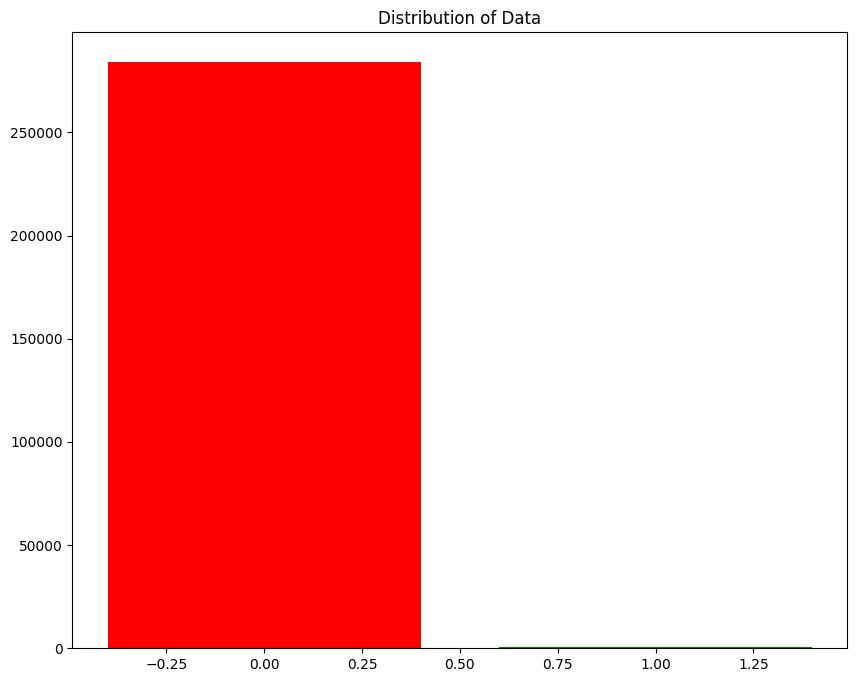

In [8]:
rcParams['figure.figsize'] = 10, 8
plt.bar(Data['Class'].unique(), Data['Class'].value_counts(),color=['red','green'])
plt.title("Distribution of Data")
plt.show()


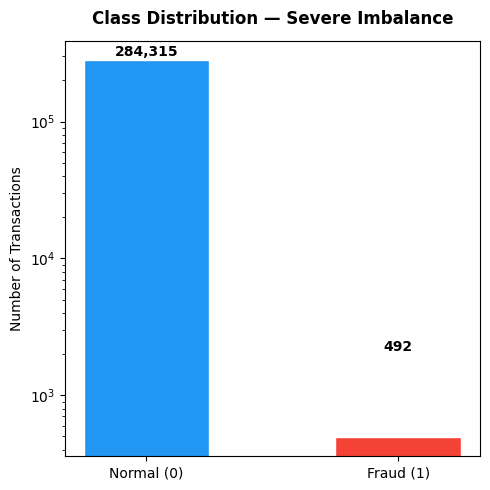

In [9]:
counts = Data["Class"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Normal (0)", "Fraud (1)"], counts.values,
              color=["#2196F3", "#F44336"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Class Distribution — Severe Imbalance", fontweight="bold", pad=12)
ax.set_ylabel("Number of Transactions")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=130)

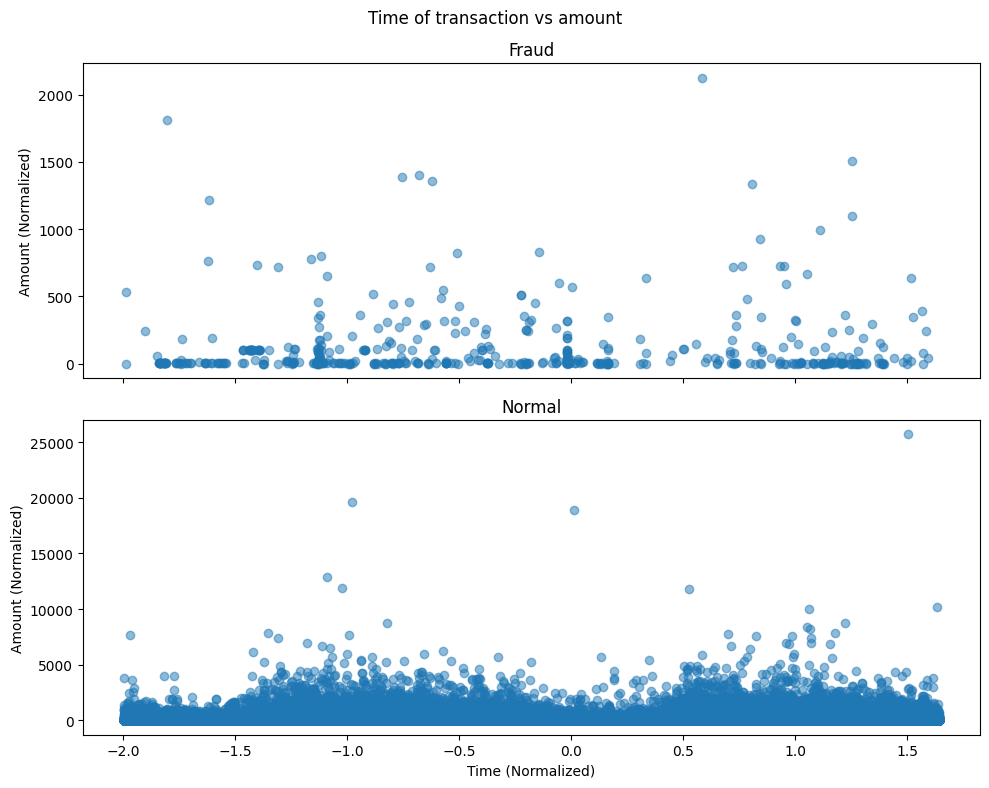

In [10]:
# Normalize the Time column in df as it was not dropped from this dataframe
df['Time_norm'] = StandardScaler().fit_transform(df['Time'].values.reshape(-1, 1))

# Create fraud and normal dataframes from df
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
figure.suptitle("Time of transaction vs amount")

ax1.scatter(fraud.Time_norm, fraud.Amount, alpha=0.5)
ax1.set_title("Fraud")
ax1.set_ylabel("Amount (Normalized)")

ax2.scatter(normal.Time_norm, normal.Amount, alpha=0.5)
ax2.set_title("Normal")
ax2.set_xlabel("Time (Normalized)")
ax2.set_ylabel("Amount (Normalized)")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import IsolationForest

# Calculate the fraud ratio
fraud_ratio = Data['Class'].value_counts()[1] / len(Data)

iso=IsolationForest(n_estimators=200,
                    contamination=fraud_ratio,
                    max_features=1.0,
                    max_samples="auto",
                    random_state=42,
                    n_jobs=-1)

In [12]:
X=df.drop("Class",axis=1)

In [13]:
iso.fit(X)

IsolationForest(contamination=np.float64(0.001727485630620034),
                n_estimators=200, n_jobs=-1, random_state=42)

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1696/2275851743.py:11: SyntaxWarning: invalid escape sequence '\$'
  label=f"Median: \${subset.median():.2f}")


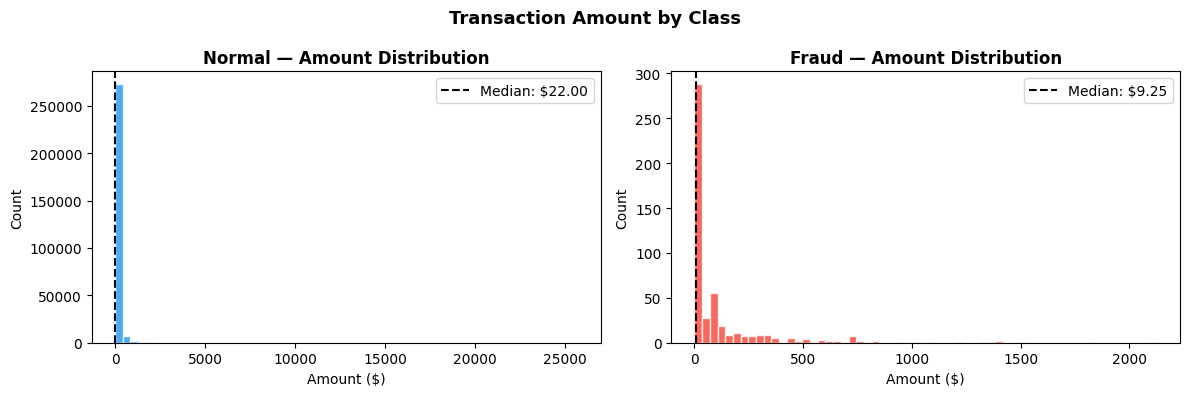

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls, color, label in zip(
    axes, [0, 1], ["#2196F3", "#F44336"], ["Normal", "Fraud"]
):
    subset = Data[Data["Class"] == cls]["Amount"]
    ax.hist(subset, bins=60, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{label} — Amount Distribution", fontweight="bold")
    ax.set_xlabel("Amount ($)")
    ax.set_ylabel("Count")
    ax.axvline(subset.median(), color="black", linestyle="--",
               label=f"Median: \${subset.median():.2f}")
    ax.legend()
plt.suptitle("Transaction Amount by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_amount_distribution.png", dpi=130)
plt.show()

In [15]:
X = Data.drop("Class", axis=1)
Y = Data["Class"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [20]:
HP = {"criterion": ["gini", "entropy"], "max_depth": [1, 2, 3, 4, 5, 10, 15, 20]}

Tree = GridSearchCV(DecisionTreeClassifier(), param_grid=HP, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1)
Tree.fit(x_train, y_train)

print("The best Parameter combined is: ", Tree.best_params_)
print("The best Score combined is: ", Tree.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best Parameter combined is:  {'criterion': 'entropy', 'max_depth': 3}
The best Score combined is:  0.9376006650001395


In [21]:
y_pred = Tree.predict(x_test)

In [22]:
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))

#Calculate sensitivity and specificity

total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56852    12]
 [   21    77]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.87      0.79      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.999420666409185
Sensitivity :  0.9997889701744513
Specificity :  0.7857142857142857


In [24]:
# pip install graphviz

In [23]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz

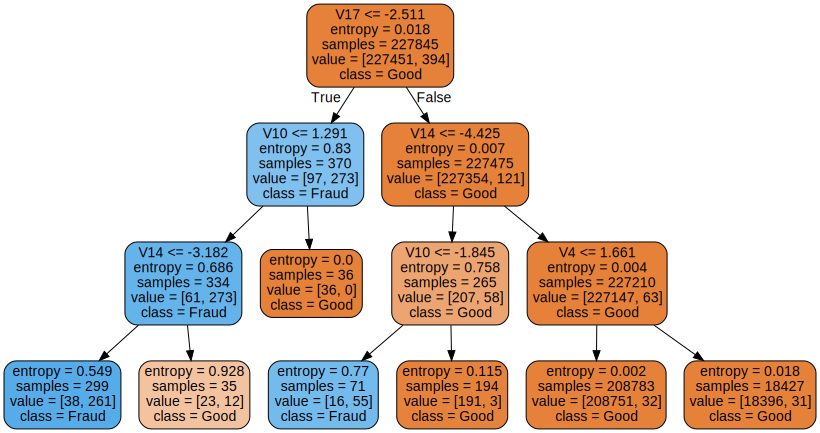

In [26]:
best_model = Tree.best_estimator_

dot_data = export_graphviz(best_model, out_file=None, feature_names=x_train.columns, class_names=["Good", "Fraud"], filled=True, rounded=True)

graph = graphviz.Source(dot_data)
graph

In [35]:
print("The best Parameter combined is: ", Tree.best_params_)
print("The best Score combined is: ", Tree.best_score_)

best_model = Tree.best_estimator_

The best Parameter combined is:  {'criterion': 'entropy', 'max_depth': 3}
The best Score combined is:  0.9376006650001395


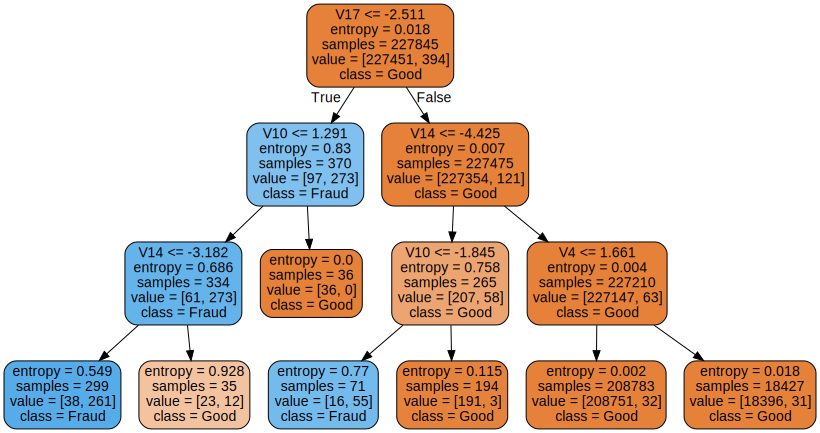

In [37]:
single_tree = best_model

dot_data = export_graphviz(single_tree, out_file=None, feature_names=x_train.columns, class_names=["Good", "Fraud"], filled=True, rounded=True)

graph = graphviz.Source(dot_data)
graph

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X_df) and target (y_df) from the original DataFrame for pipeline usage
X_df = df.drop('Class', axis=1)
y_df = df['Class']

# Define numerical_cols and categorical_cols based on the *processed* X_df
categorical_cols_pipeline = X_df.select_dtypes(include='object').columns
numerical_cols_pipeline = X_df.select_dtypes(include=['int64', 'float64']).columns

# Create the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_pipeline),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_pipeline)
    ],
    remainder='drop' # Drop any columns not explicitly transformed
)

# Create the pipeline with the preprocessor and Logistic Regression model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Split data *after* defining X_df and y_df for consistency with pipeline
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_df, y_df, test_size=0.2, random_state=42, stratify=y_df
)

logistic_model.fit(X_train_pipe, y_train_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Time_norm'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])